# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [5]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "Không tìm thấy '" + path + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)

pandas 3.0.5 | numpy 2.5.3 | matplotlib 3.11.2 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

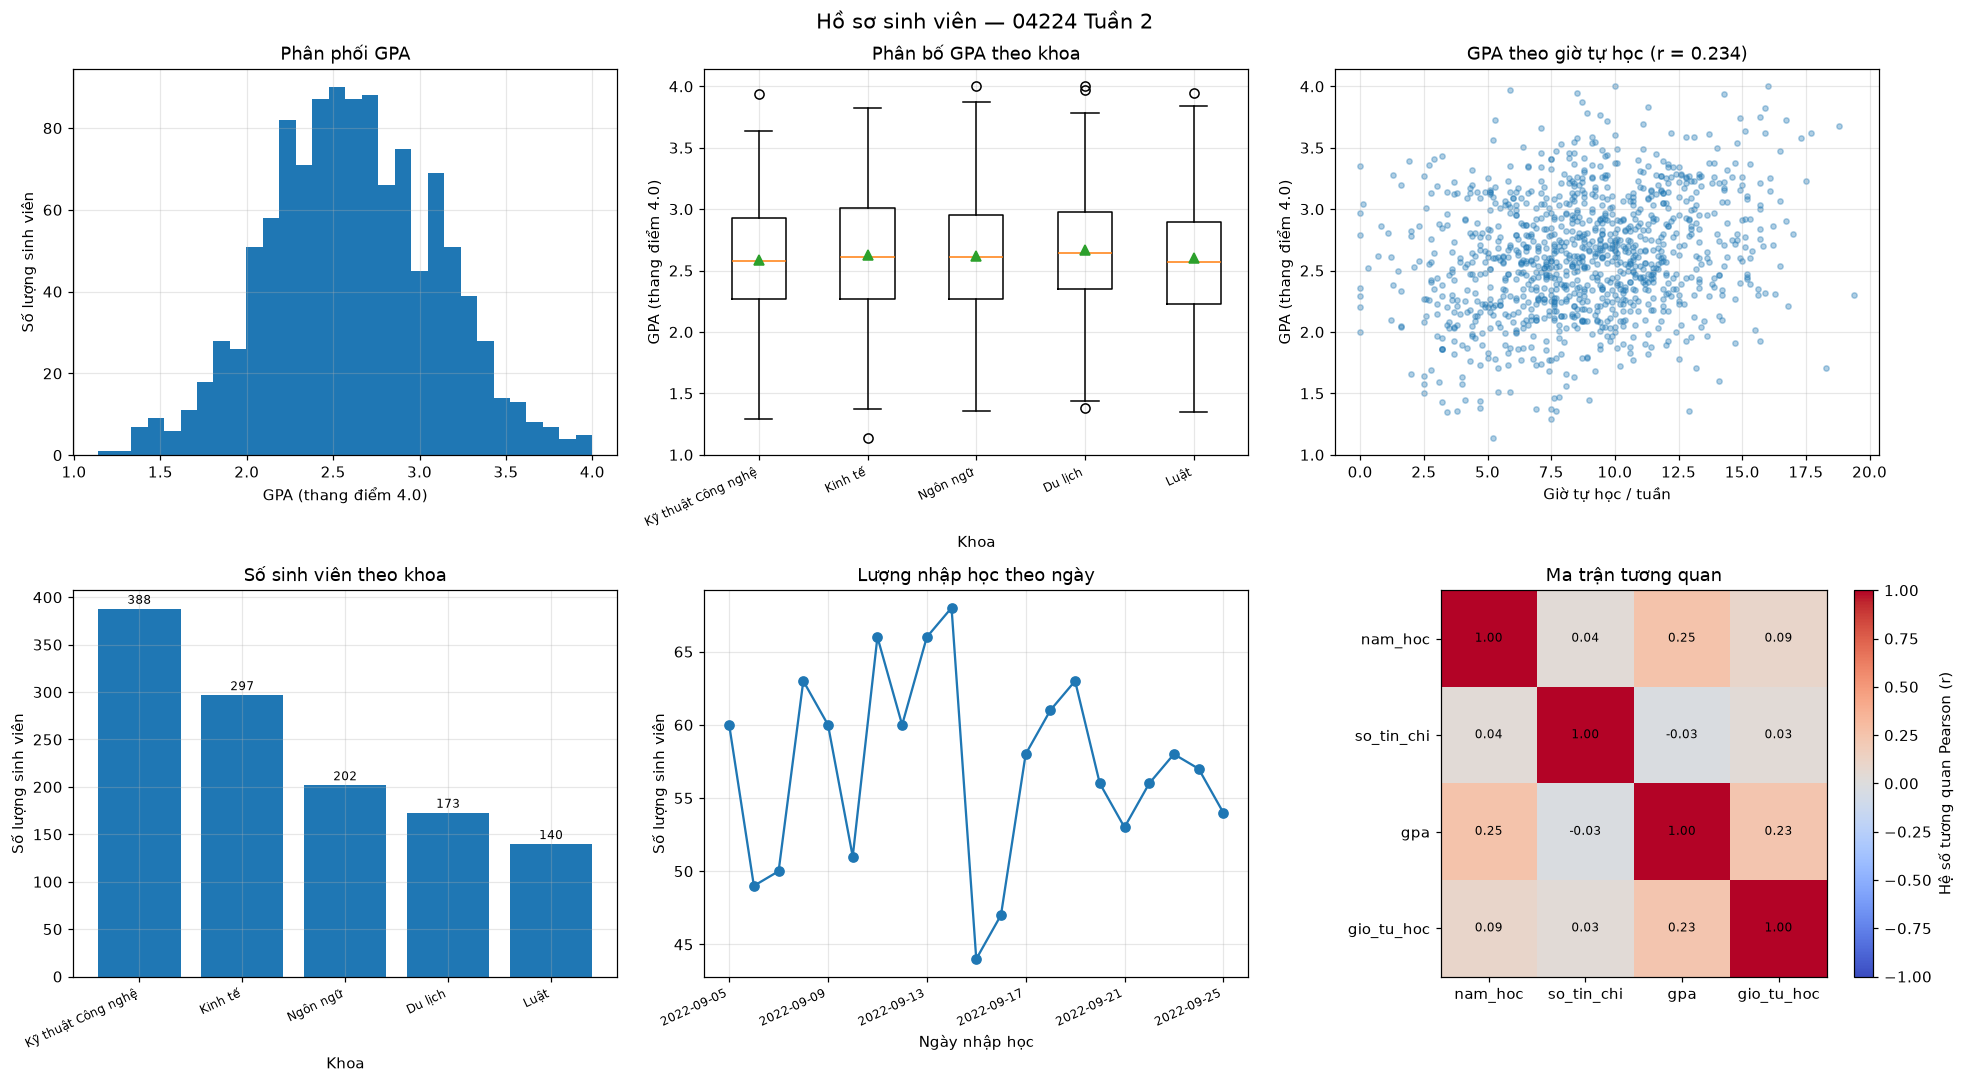

In [6]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
# TODO: ax.hist(...) với bins=30
ax.hist(sv_gpa["gpa"], bins=30)

# TODO: set_xlabel / set_ylabel / set_title — nhãn phải ghi cả ĐƠN VỊ
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số lượng sinh viên")
ax.set_title("Phân phối GPA")

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
# TODO: ax.boxplot([...], tick_labels=faculties, showmeans=True)
#       Gợi ý: dựng list GPA của từng khoa bằng list comprehension trên `faculties`.
box_data = []
for ten_khoa in faculties:
    sinh_vien_trong_khoa = sv_gpa[sv_gpa["khoa"] == ten_khoa]
    diem_gpa_cua_khoa = sinh_vien_trong_khoa["gpa"]
    box_data.append(diem_gpa_cua_khoa)
ax.boxplot(box_data, tick_labels=faculties, showmeans=True)

# TODO: nhãn + title
ax.set_xlabel("Khoa")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("Phân bố GPA theo khoa")

plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA -----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
# TODO: ax.scatter(...). 1145 điểm sẽ chồng lên nhau -> dùng s=12, alpha=0.35
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35)

# TODO: tính r = d3["gio_tu_hoc"].corr(d3["gpa"]) và đưa vào title
r = d3["gio_tu_hoc"].corr(d3["gpa"])

# TODO: nhãn + title
ax.set_xlabel("Giờ tự học / tuần")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title(f"GPA theo giờ tự học (r = {r:.3f})")

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
danh_sach_ten_khoa = counts.index
danh_sach_so_luong = counts.values
# TODO: ax.bar(...)
ax.bar(danh_sach_ten_khoa, danh_sach_so_luong)

# TODO: ghi con số lên đầu mỗi cột bằng ax.text(...)
for vi_tri in range(len(danh_sach_ten_khoa)):
    so_luong = danh_sach_so_luong[vi_tri]
    ax.text(vi_tri, so_luong + 5, str(so_luong), ha="center", fontsize=8)

# TODO: nhãn + title
ax.set_xlabel("Khoa")
ax.set_ylabel("Số lượng sinh viên")
ax.set_title("Số sinh viên theo khoa")

plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
# TODO: enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()

# TODO: ax.plot(..., marker="o")
ax.plot(enrol.index, enrol.values, marker="o")

# TODO: nhãn + title
ax.set_xlabel("Ngày nhập học")
ax.set_ylabel("Số lượng sinh viên")
ax.set_title("Lượng nhập học theo ngày")

plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
# TODO: M = sv[num_cols].corr().to_numpy()
M = sv[num_cols].corr().to_numpy()

# TODO: im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)

# TODO: đặt tên biến lên cả hai trục bằng set_xticks/set_xticklabels và set_yticks/set_yticklabels
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)

# TODO: ghi giá trị vào từng ô bằng hai vòng for lồng nhau + ax.text(...)
so_luong_bien = len(num_cols)
for dong in range(so_luong_bien):
    for cot in range(so_luong_bien):
        gia_tri = M[dong, cot]
        ax.text(cot, dong, f"{gia_tri:.2f}", ha="center", va="center", color="black", fontsize=8)

# TODO: title, và ax.grid(False) cho heatmap
ax.set_title("Ma trận tương quan")
ax.grid(False)

# TODO: cbar = fig.colorbar(im, ax=ax, fraction=0.046)  rồi cbar.set_label(...)
#       Ở ô này, ĐƠN VỊ nằm trên colorbar chứ không nằm trên trục -> colorbar bắt buộc có nhãn.
cbar = fig.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label("Hệ số tương quan Pearson (r)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
# TODO: lưu hình — fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

> *(Nhấp đúp vào ô này để sửa. Một câu cho mỗi ô, nói **điều biểu đồ cho biết**, không mô tả lại hình dạng. "Phân phối hình chuông" không phải nhận định; "GPA tập trung quanh 2.6, rất ít sinh viên trên 3.5" mới là nhận định.)*

1. Histogram GPA: Điểm GPA của đa số sinh viên tập trung chủ yếu ở mức khá từ 2.2 đến 2.8, rất ít người đạt điểm xuất sắc trên 3.5 hoặc bị điểm kém đưới 1.5
2. Box plot theo khoa: Mặt bằng điểm số chung của cả 5 khoa khá đồng đều nhau, điểm trung bình đều xoay quanh mốc 2.6, không có khoa nào rỏ ra vượt trội hay yếu kém hơn hẳn
3. Scatter giờ tự học – GPA: Sinh viên dành nhiều thời gian tự học có xu hướng đạt điểm cao hơn một chút, nhưng mức độ ảnh hưởng không tuyệt đối vì vẫn có nhiều bạn học ít nhưng điểm vẫn cao và ngược lại
4. Bar quy mô khoa: Khoa Kỹ thuật Công nghệ thu hút đông sinh viên nhất với 388 người, đông gấp gần 3 lần so với khoa có ít sinh viên nhất là khoa Luật với 140 người
5. Line nhập học: Lượng sinh viên đến làm thủ tục nhập học biến động mạnh theo từng ngày, đạt đỉnh cao nhất vào khoảng giữa tháng 9 rồi bất ngờ sụt giảm sâu ngay ngày hôm sau
6. Heatmap tương quan: Điểm GPA có xu hướng tăng theo năm học và giờ tự học, trong khi việc đăng ký học nhiều hay ít tín chỉ hoàn toàn không ảnh hưởng gì đến điểm số

---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [8]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng.

    Trả về DataFrame có index là tên cột và các cột:
    dtype, n_missing, pct_missing, n_unique, top_values
    """
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        # TODO: vc = k giá trị phổ biến nhất của s   (gợi ý: s.value_counts().head(k))
        vc = s.value_counts().head(k)

        # TODO: top = chuỗi mô tả vc, ví dụ "'Online' x510, 'Cửa hàng' x279"
        #       Nhớ trường hợp cột rỗng hoặc toàn NaN -> vc rỗng.
        top = ", ".join(f"'{val}' x{count}" for val, count in vc.items()) if not vc.empty else ""

        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   int(s.isnull().sum()),   # TODO: số ô thiếu, kiểu int
            "pct_missing": round(s.isnull().sum() / n * 100, 2) if n > 0 else 0,   # TODO: tỉ lệ thiếu tính theo %, làm tròn 2 chữ số.
                                    #       Cẩn thận: n có thể bằng 0 -> đừng chia cho 0.
            "n_unique":    s.nunique(dropna=True),   # TODO: số giá trị duy nhất (không tính NaN)
            "top_values":  top,   # TODO: dùng `top` ở trên
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                        "pct_missing", "n_unique",
                                        "top_values"]).set_index("column")

In [9]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  '2200001' x1, '2200002' x1, '2200003' x1, '220...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4             '1' x361, '2' x318, '3' x285, '4' x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13  '23' x103, '24' x103, '19' x103, '16' x101, '1...
gpa            float64         55         4.58       226  '2.61' 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

> *(Nhấp đúp để sửa.)*

1. Cột nào của `banhang_raw.csv` có `dtype` **không đúng với ý nghĩa thực tế** của nó? Vì sao pandas lại hiểu như vậy?
Có 2 cột bị sai kiểu dữ liệu:
    Cột thanh_tien mang ý nghĩa là tiền thì phải là số, nhưng lại có dtype object là chuỗi văn bản. Pandas hiểu lầm vì trong dữ liệu đang có các ký tự chữ cái như chữ "đ" hoặc dấu chấm phẩy

    Cột so_luong mang ý nghĩa số đếm phải là số nguyên int, nhưng lại có dtype float64 là số thập phân. Pandas tự động ép sang số thập phân vì cột này đang có 30 ô bị bỏ trống, mà trong Python, NaN mặc định được xếp vào kiểu float

2. `ma_don` có bao nhiêu giá trị duy nhất, và tệp có bao nhiêu dòng? Hai con số đó cho bạn biết điều gì?
Cột ma_don chỉ có 900 giá trị duy nhất, trong khi tệp dữ liệu có tới 928 dòng. Hai con số này bị lệch nhau chứng tỏ tệp dữ liệu đang có chứa 28 dòng bị trùng lặp hoàn toàn. Mã đơn hàng vốn dĩ là định danh duy nhất, không thể có 1 mã đơn lại xuất hiện ở 2 dòng khác nhau được

3. Cột `kenh` có bao nhiêu giá trị duy nhất, và theo bạn **thực tế** có bao nhiêu kênh bán hàng?
Bảng hồ sơ báo cáo cột kenh đang có 4 giá trị duy nhất bao gồm: 'Online', 'Cửa hàng', 'ONLINE', 'Cua hang'. Tuy nhiên, trên thực tế rõ ràng chỉ có 2 kênh bán hàng mà thôi. Việc nó sinh ra thành 4 nhãn là do người nhập liệu gõ không thống nhất chữ hoa hoặc chữ thường và gõ thiếu dấu tiếng Việt.

---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [10]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

# TODO: đếm số dòng trùng lặp hoàn toàn        -> df.duplicated().sum()
print("Số dòng trùng lặp hoàn toàn:", df.duplicated().sum())

# TODO: liệt kê các cách viết của cột `kenh`    -> df["kenh"].value_counts()
#       In bằng repr() để nhìn thấy dấu cách thừa nếu có.
print("Kênh:", df["kenh"].value_counts().apply(repr))

# TODO: đếm số dòng `thanh_tien` còn chứa chữ "đ"
print("Số dòng `thanh_tien` còn chứa chữ 'đ':", df["thanh_tien"].str.contains("đ").sum())

# TODO: đếm số dòng `ngay` ở dạng DD/MM/YYYY   -> str.fullmatch(r"\d{2}/\d{2}/\d{4}")
print("Số dòng `ngay` ở dạng DD/MM/YYYY:", df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())

Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7  '1.0' x204, '4.0' x180, '3.0' x178, '2.0' x165...
don_gia       int64          0         0.00         6  '450000' x170, '3200000' x158, '1450000' x154,...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [11]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

# TODO: df = ...            (bỏ dòng trùng, rồi .reset_index(drop=True))
df = df.drop_duplicates().reset_index(drop=True)

removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"

Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [12]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Bẫy: .str.title() không cứu được chuỗi mất dấu
print("\nBẫy:", repr("Cua hang".title()), "!=", repr("Cửa hàng"))

# TODO: key = df["kenh"] sau khi .str.strip() rồi .str.casefold()
# print("Sau strip + casefold còn lại:", sorted(key.unique()))
key = df["kenh"].str.strip().str.casefold()

KENH_MAP = {
    # TODO: điền đủ các khoá viết thường ở trên, ánh xạ về đúng 2 nhãn
    #       "Online" và "Cửa hàng". Bản mất dấu phải ánh xạ tay.
    "online": "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng"
}

# TODO: df["kenh"] = key.map(KENH_MAP)
df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "map() sinh ra NaN -> còn chính tả chưa liệt kê trong KENH_MAP"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330

Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Bẫy: 'Cua Hang' != 'Cửa hàng'

Sau : 'Online' x570, 'Cửa hàng' x330


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [13]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

# TODO: df["thanh_tien"] = pd.to_numeric(...)
#   Ba việc phải làm với chuỗi trước khi ép kiểu:
#     1. bỏ chữ "đ"
#     2. bỏ dấu "."   <- ở đây "." là phân cách nghìn, KHÔNG phải dấu thập phân
#     3. .str.strip() cho sạch dấu cách
#   Gợi ý: .str.replace("đ", "", regex=False) — nhớ regex=False, vì "." trong regex
#          có nghĩa là "ký tự bất kỳ" và sẽ xoá sạch cả chuỗi.
#   Để errors="raise" (mặc định): nếu còn ký tự lạ, ta muốn biết ngay chứ không muốn NaN im lặng.
df["thanh_tien"] = pd.to_numeric(
    df["thanh_tien"].astype(str)
        .str.replace("đ", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.strip(),
    errors="raise"
)

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000

Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [14]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))
# TODO: chỉ có 7 ngày thật sự không tồn tại. Vậy 113 dòng còn lại đi đâu?
#       Viết câu trả lời vào ô markdown bên dưới.

# TODO: parsed = pd.to_datetime(...) — nói rõ hai điều với pandas:
#         format="mixed"   : cột này có nhiều hơn một định dạng
#         dayfirst=True    : "03/04/2024" là 3 tháng 4, không phải 4 tháng 3
#       và giữ errors="coerce" để 7 ngày không tồn tại thành NaT.
# print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
# print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())
parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

# TODO: trước khi quyết định, hãy đo cái giá của việc xoá 7 dòng đó:
#       tổng `thanh_tien` của chúng là bao nhiêu?
tong_thanh_tien_7dong = df.loc[parsed.isna(), "thanh_tien"].sum()
print("Tổng `thanh_tien` của 7 dòng không tồn tại:", format(int(tong_thanh_tien_7dong), ",").replace(",", "."), "đ")

# TODO: df["ngay"] = parsed      (quyết định của bạn: giữ dòng hay xoá dòng?)
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"

YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}
Tổng `thanh_tien` của 7 dòng không tồn tại: 44.400.000 đ


### Quyết định của bạn về 7 ngày không tồn tại

> *(Nhấp đúp để sửa. Câu hỏi không phải "bạn làm gì" mà là "vì sao".)*

1. Ở Bẫy 2, `errors="coerce"` cho 120 `NaT` nhưng chỉ 7 ngày thật sự sai. 113 dòng kia đi đâu và vì sao?
113 dòng kia bị biến thành NaT oan uổng. Vì Pandas đọc vào dòng đầu tiên thấy định dạng ISO là YYYY-MM-DD, nó liền "khóa" định dạng này lại. Do đó, tất cả 113 dòng mang định dạng hợp lệ nhưng viết kiểu Việt Nam theo định dạng DD/MM/YYYY phía sau đều bị nó coi là rác và ép thành NaT

2. Bạn chọn **xóa dòng** hay **giữ dòng, để `ngay = NaT`**?
Chọn giữ nguyên dòng, chấp nhận để cột ngay bị thiếu (NaT)

3. Lý do:
Vì tổng thanh_tien của 7 đơn hàng bị ghi sai ngày là 31/02/2024 lên tới 44.400.000 VNĐ. Nếu xóa bỏ dòng, ta sẽ làm mất dữ liệu doanh thu thực tế, gây sai lệch sổ sách kế toán nghiêm trọng

4. Quyết định của bạn ảnh hưởng thế nào đến (a) tổng doanh thu cả năm, và (b) biểu đồ doanh thu theo tháng?
(a) Tổng doanh thu cả năm: Được bảo toàn chính xác.
(b) Biểu đồ doanh thu theo tháng: Sẽ bị khuyết mất 7 đơn hàng do trị giá 44,4 triệu này vì chúng bị rơi vào trạng thái NaT, không xác định được thuộc tháng nào để vẽ lên biểu đồ.

## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [15]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

# ĐỪNG gõ fillna() ngay. Câu hỏi đầu tiên luôn là:
#   "Giá trị này có SUY RA được từ cột khác không?"
# Bạn đã có `thanh_tien` (số, ở bước 3.4) và `don_gia`. Chúng nói gì về `so_luong`?

# TODO: qty_implied = ...          (một phép chia)
qty_implied = df["thanh_tien"] / df["don_gia"]

# TODO: kiểm tra qty_implied có phải số nguyên hết không -> (qty_implied % 1 == 0).all()
print("qty_implied có phải số nguyên hết không:", (qty_implied % 1 == 0).all())

# TODO: in khoảng giá trị suy ra (min, max). Nó có hợp lý với một đơn hàng bán lẻ không?
print("Khoảng giá trị suy ra (min, max):", int(qty_implied.min()), ",", int(qty_implied.max()))

# TODO: đếm xem bao nhiêu dòng mà `so_luong` sẵn có ĐÃ KHỚP với qty_implied.
#       Nếu con số này rất lớn, bạn vừa tìm được một cột kiểm chứng đáng tin.
so_luong_match = (df["so_luong"] == qty_implied).sum()
print("Số dòng `so_luong` sẵn có KHỚP với qty_implied:", int(so_luong_match))

# TODO: điền `so_luong` cho 30 dòng thiếu. Nếu suy ra được thì KHÔNG ước lượng.
#       df.loc[need, "so_luong"] = ...
need = df["so_luong"].isna()
df.loc[need, "so_luong"] = qty_implied[need]

# `tinh_tp` thì không có cột nào suy ra được. Hai lựa chọn thường gặp:
#   - fillna(mode)  -> bịa ra 52 đơn cho tỉnh đông nhất, làm sai bảng xếp hạng theo tỉnh
#   - một nhãn riêng -> giữ được sự thật "không biết"
# TODO: df["tinh_tp"] = ...        (viết lý do lựa chọn vào ô markdown bên dưới)
df["tinh_tp"] = df["tinh_tp"].fillna("không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"

so_luong thiếu: 30
tinh_tp  thiếu: 52
qty_implied có phải số nguyên hết không: True
Khoảng giá trị suy ra (min, max): 1 , 5
Số dòng `so_luong` sẵn có KHỚP với qty_implied: 863

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

> *(Nhấp đúp để sửa.)*

1. `thanh_tien / don_gia` cho kết quả thế nào? Bao nhiêu dòng `so_luong` sẵn có đã khớp với nó?
Phép chia thanh_tien / don_gia cho kết quả đều là các số nguyên nằm trong khoảng từ 1 đến 5. Có 863/900 dòng dữ liệu hiện tại đã khớp với phép tính này

2. Vì sao ở đây **không nên** dùng `fillna(median)` cho `so_luong`?
Vì so_luong có mối liên hệ trực tiếp với thanh_tien và don_gia. Thay vì dùng giá trị ước lượng như trung vị, ta có thể tính toán ngược lại để tìm ra số lượng thực tế dựa trên dữ liệu sẵn có

3. Với `tinh_tp` bạn chọn phương án nào trong ba phương án ở bảng trên?
Chọn gán một nhãn riêng là chữ "Không rõ"

4. Lý do, và điều gì trong báo cáo sẽ sai nếu bạn chọn phương án khác?
Do không có dữ liệu đối chiếu để suy ra tỉnh/thành phố thực sự của 52 đơn hàng này. Nếu chọn xóa dòng, báo cáo sẽ bị hụt khoảng 5,8% tổng doanh thu. Nếu chọn điền theo mode, các đơn hàng này sẽ bị cộng dồn vào một tỉnh cụ thể, làm sai lệch kết quả thống kê doanh thu theo từng địa phương

## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [16]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))
print("IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.\n")

suspect = df[flag].copy()
# TODO: thêm cột suspect["qty_implied"] = thanh_tien / don_gia  (ép về int)
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)

print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien"]].to_string(index=False))

# Nhìn bảng trên và trả lời bằng BẰNG CHỨNG, không bằng cảm tính:
#   - Nếu 500 là đơn sỉ THẬT thì `thanh_tien` phải bằng bao nhiêu? Nó có bằng như vậy không?
#   - Nếu -2 là hàng trả lại THẬT thì dấu của `thanh_tien` phải là gì? Nó có đúng dấu đó không?
# TODO: viết lập luận vào ô markdown bên dưới, RỒI mới sửa.

# TODO: sửa 7 dòng này. Lưu ý: "sửa" không nhất thiết là "xoá" —
#       nếu giá trị đúng khôi phục được thì khôi phục, đừng vứt cả dòng.
#       df.loc[flag, "so_luong"] = ...
df.loc[flag, "so_luong"] = (df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]).astype(int)

# TODO: df["so_luong"] = df["so_luong"].astype("int64")
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0

Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.

 ma_don   san_pham  so_luong  don_gia  thanh_tien
DH00299      Chuột      -2.0   250000      250000
DH00165   Tai nghe      -2.0   690000     2070000
DH00089     Webcam     500.0   890000     4450000
DH00652   Tai nghe     500.0   690000      690000
DH00263     Webcam     500.0   890000     4450000
DH00764 Ổ cứng SSD     500.0  1450000     7250000
DH00226   Bàn phím      -2.0   450000     1800000

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}


### Lập luận của bạn về 7 dòng ngoại lai

> *(Nhấp đúp để sửa. Với **mỗi** nhóm, nêu giả thuyết, nêu bằng chứng kiểm chứng, rồi mới nêu kết luận.)*

**Nhóm A — 4 dòng `so_luong = 500`**
- Giả thuyết "đây là đơn sỉ thật" dự đoán `thanh_tien` phải bằng bao nhiêu?
Dự đoán thanh_tien phải rất lớn, cụ thể là bằng đúng 500 × don_gia

- Thực tế `thanh_tien` bằng bao nhiêu?
Thực tế thanh_tien thu về rất nhỏ, chỉ tương đương với giá trị của 1 hoặc 5 sản phẩm

- Kết luận, và cách xử lý:
Đây là lỗi nhập liệu do thao tác gõ thừa hai phím 0. Cách xử lý là khôi phục số lượng thực tế bằng phép chia thanh_tien / don_gia

**Nhóm B — 3 dòng `so_luong = -2`**
- Giả thuyết "đây là hàng trả lại thật" dự đoán dấu của `thanh_tien` là gì?
Dự đoán thanh_tien phải mang dấu âm để thể hiện dòng tiền xuất ra hoàn trả cho khách

- Thực tế dấu của `thanh_tien` là gì?
Thực tế thanh_tien vẫn mang giá trị dương bình thường

- Kết luận, và cách xử lý:
Đây là lỗi nhập liệu do gõ thừa dấu trừ -. Cách xử lý là tính lại số lượng thực tế bằng phép chia thanh_tien / don_gia

**Câu hỏi cuối.** Nếu có một dòng `so_luong = 500` **và** `thanh_tien = 500 × don_gia` thì bạn làm gì với nó?
Giữ nguyên toàn bộ dòng dữ liệu này và không can thiệp. Khi hệ thức kế toán giữa số lượng, đơn giá và thành tiền hoàn toàn khớp nhau, đây là bằng chứng xác thực cho một đơn hàng mua sỉ hợp lệ. Việc xóa hay sửa đổi sẽ làm hỏng tính toàn vẹn của dữ liệu doanh thu

## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [18]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
# TODO: recomputed = so_luong * don_gia
recomputed = df["so_luong"] * df["don_gia"]

# TODO: mismatch = recomputed khác thanh_tien
# print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
# assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"
mismatch = recomputed != df["thanh_tien"]
print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
# TODO: df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")

Số dòng còn lệch: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

> **Ô này được chấm ngang với phần code.** Code cho biết bạn đã làm **gì**; nhật ký cho biết **vì sao** — và đó mới là thứ người đọc báo cáo cần để tin vào con số của bạn.
>
> Điền đủ cột "Lý do". Một dòng chỉ ghi "để dữ liệu sạch hơn" là một dòng trống.

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn |Dùng .drop_duplicates() loại bỏ|Tránh việc ghi nhận doanh thu hai lần cho cùng một giao dịch| 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh |Viết thường, xóa khoảng trắng thừa và .map() ánh xạ tay|Chuẩn hóa sự thiếu nhất quán do lỗi gõ phím sai chữ hoa/thường và mất dấu tiếng Việt| 4 → 2 nhãn |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng |Xóa ký tự "đ", dấu "." và ép sang kiểu định lượng (int64)|Các hàm thống kê chỉ có thể tính toán toán học trên kiểu dữ liệu số| `str` → `int64` |
| 4 | `ngay` trộn 2 định dạng |Ép ngày với format="mixed" và dayfirst=True|Giúp hệ thống nhận diện chính xác cả định dạng ISO Năm-Tháng-Ngày lẫn định dạng truyền thống Ngày/Tháng/Năm|Khôi phục định dạng ngày cho toàn bảng|
| 5 | 7 dòng ghi `31/02/2024` |Giữ nguyên dòng, sử dụng errors="coerce" để ép thành NaT|Đây là các đơn hàng có doanh thu thật hơn 44 triệu đồng. Việc xóa bỏ dòng sẽ làm hao hụt sổ sách kế toán|Dữ liệu xuất hiện 7 ô thiếu ở cột ngay|
| 6 | `so_luong` thiếu 30 ô |Khôi phục bằng công thức thanh_tien / don_gia|Mối quan hệ giữa 3 biến này là hằng đẳng thức kế toán chính xác 100%, thay thế hoàn toàn cho các phương pháp điền ước lượng| 30 → 0 |
| 7 | `tinh_tp` thiếu 52 ô |Tạo nhãn riêng: Điền chữ "Không rõ"|Không có biến phụ thuộc để suy luận. Gán bừa bằng Mode sẽ làm sai lệch báo cáo phân bổ doanh thu theo địa phương| 52 → 0 |
| 8 | `so_luong` có 4 giá trị `500` |Sửa lại bằng công thức thanh_tien / don_gia|Đối chiếu với thanh_tien thu về rất nhỏ, chứng tỏ đây không phải đơn hàng sỉ mà do lỗi gõ thừa số "0"|Giá trị được trả về [1..5]|
| 9 | `so_luong` có 3 giá trị `-2` |Sửa lại bằng công thức thanh_tien / don_gia|Doanh thu vẫn mang dấu dương không phải dòng tiền hoàn trả cho khách, chứng tỏ nhân viên gõ thừa dấu trừ|Giá trị mang dấu dương|

**Ba câu phải trả lời**

1. Quyết định nào trong bảng trên có thể khiến một người khác, làm cùng tệp này, ra **con số khác** bạn?
Việc xử lý 7 dòng lỗi ngày 31/02/2024. Nếu người phân tích khác chọn phương pháp loại bỏ dòng bị khuyết, tổng doanh thu báo cáo của họ sẽ thấp hơn thực tế 44.400.000 VNĐ so với kết quả hiện tại

2. Quyết định nào bạn **kém chắc chắn nhất**, và bạn cần thêm thông tin gì để chắc?
Quyết định điền "Không rõ" cho 52 ô thiếu ở cột tinh_tp. Dù đây là giải pháp an toàn về mặt thống kê tổng thể, tập dữ liệu vẫn bị mất thông tin chi tiết. Để xử lý triệt để, cần quyền truy cập đối chiếu với cơ sở dữ liệu CRM Quản lý khách hàng hoặc mã vận đơn để truy xuất địa chỉ giao hàng gốc

3. Tuần sau nhận thêm 900 dòng mới cùng định dạng: notebook của bạn chạy lại được **không sửa dòng code nào** chứ? Nếu không, chỗ nào phải sửa?
Phần lớn quy trình sẽ tự động hóa được hoàn toàn, nhưng sẽ phải kiểm tra và cập nhật lại từ điển KENH_MAP ở bước 3.3. Nếu trong 900 dòng mới xuất hiện thêm một kiểu gõ sai chính tả lạ lẫm khác ví dụ: "onl", "cua hng", lệnh .map() hiện tại sẽ không nhận diện được và trả về NaN, buộc phải khai báo bổ sung nhãn mới vào từ điển

---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [27]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
# TODO: dựng bảng `pattern` gồm, cho mỗi giá trị của `nam_hoc`:
#         n_students        số sinh viên
#         n_missing         số sinh viên thiếu GPA
#         missing_rate_%    tỉ lệ thiếu, làm tròn 2 chữ số
#         gpa_mean_observed GPA trung bình của phần quan sát được
#       Gợi ý: sv.groupby("nam_hoc").agg(...) rồi thêm cột.
# print(pattern)
pattern = sv.groupby("nam_hoc").agg(
    n_students=("mssv", "size"),
    n_missing=("gpa", lambda x: x.isna().sum()),
    gpa_mean_observed=("gpa", "mean")
)
pattern["missing_rate_%"] = (pattern["n_missing"] / pattern["n_students"] * 100).round(2)

print("Bảng phân tích thiếu hụt GPA theo năm học")
print(pattern)

# TODO: in tổng số thiếu và tỉ lệ thiếu trên toàn bộ 1200 dòng.
tong_thieu = sv["gpa"].isna().sum()
ti_le_thieu = round(tong_thieu / len(sv) * 100, 2)
print("Tổng số sinh viên thiếu GPA:", tong_thieu)
print("Tỉ lệ thiếu trên toàn bộ:", ti_le_thieu, "%")
print("=> Nhận xét: Tỉ lệ thiếu KHÔNG ĐỀU. Năm 1 thiếu nhiều nhất là 10.8%, và nhóm này có GPA trung bình thấp nhất là 2.48")

# TODO: nhìn cột missing_rate_% — nó có đều giữa các năm không?
#       Và nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại?

Bảng phân tích thiếu hụt GPA theo năm học
         n_students  n_missing  gpa_mean_observed  missing_rate_%
nam_hoc                                                          
1               361         39           2.481522           10.80
2               318          9           2.535178            2.83
3               285          4           2.693701            1.40
4               236          3           2.809528            1.27
Tổng số sinh viên thiếu GPA: 55
Tỉ lệ thiếu trên toàn bộ: 4.58 %
=> Nhận xét: Tỉ lệ thiếu KHÔNG ĐỀU. Năm 1 thiếu nhiều nhất là 10.8%, và nhóm này có GPA trung bình thấp nhất là 2.48


In [29]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

# TODO: A = (a) bỏ các dòng thiếu gpa           -> sv.dropna(subset=[...])["gpa"]
A = sv.dropna(subset=["gpa"])["gpa"]

# TODO: B = (b) điền bằng trung bình chung      -> .fillna(...)
B = sv["gpa"].fillna(sv["gpa"].mean())

# TODO: C = (c) điền bằng trung bình theo nhóm  -> .fillna(sv.groupby(...)[...].transform("mean"))
#        `transform("mean")` trả về một Series DÀI BẰNG sv, mỗi dòng mang trung bình
#        của nhóm mà nó thuộc về. Đó là lý do nó ghép thẳng được vào fillna().
C = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))

# TODO: dựng bảng `summary` so sánh n / mean / std / median của 4 cột:
#       original, A, B, C. Làm tròn 4 chữ số.
# print(summary)
summary = pd.DataFrame({
    "n": [original.count(), A.count(), B.count(), C.count()],
    "mean": [original.mean(), A.mean(), B.mean(), C.mean()],
    "std": [original.std(), A.std(), B.std(), C.std()],
    "median": [original.median(), A.median(), B.median(), C.median()]
}, index=["Gốc", "(a)", "(b)", "(c)"]).round(4)
print("Bảng so sánh các chiến lược xử lý thiếu GPA")
print(summary)

# TODO: dựng bảng `by_year` — GPA trung bình theo `nam_hoc` dưới:
#         "quan sát được", "(b) TB chung", "(c) TB nhóm"
#       Gợi ý cho (b): sv.assign(g=B).groupby("nam_hoc")["g"].mean()
#       Rồi thêm cột lệch của (b) so với phần quan sát được.
# print(by_year)
by_year = pd.DataFrame({
    "quan sát được": sv.groupby("nam_hoc")["gpa"].mean(),
    "(b) TB chung": sv.assign(g=B).groupby("nam_hoc")["g"].mean(),
    "(c) TB nhóm": sv.assign(g=C).groupby("nam_hoc")["g"].mean()
})
by_year["(b) lệch"] = by_year["(b) TB chung"] - by_year["quan sát được"]
by_year = by_year.round(4)
print("Bảng so sánh GPA trung bình theo năm học")
print(by_year)

# TODO: in tỷ trọng sinh viên năm 1 trước và sau khi áp dụng (a).
#       Đây là chỗ (a) để lộ vấn đề của nó.
ti_trong_nam1 = (sv["nam_hoc"] == 1).mean()
ti_trong_sau_nam1 = (sv.dropna(subset=["gpa"])["nam_hoc"] == 1).mean()
print("Tỷ trọng sinh viên năm 1 trước khi bỏ thiếu:", round(ti_trong_nam1 * 100, 2), "%")
print("Tỷ trọng sinh viên năm 1 sau khi bỏ thiếu:", round(ti_trong_sau_nam1 * 100, 2), "%")

Bảng so sánh các chiến lược xử lý thiếu GPA
        n    mean     std  median
Gốc  1145  2.6148  0.4871  2.6000
(a)  1145  2.6148  0.4871  2.6000
(b)  1200  2.6148  0.4758  2.6148
(c)  1200  2.6106  0.4766  2.5800
Bảng so sánh GPA trung bình theo năm học
         quan sát được  (b) TB chung  (c) TB nhóm  (b) lệch
nam_hoc                                                    
1               2.4815        2.4959       2.4815    0.0144
2               2.5352        2.5374       2.5352    0.0023
3               2.6937        2.6926       2.6937   -0.0011
4               2.8095        2.8071       2.8095   -0.0025
Tỷ trọng sinh viên năm 1 trước khi bỏ thiếu: 30.08 %
Tỷ trọng sinh viên năm 1 sau khi bỏ thiếu: 28.12 %


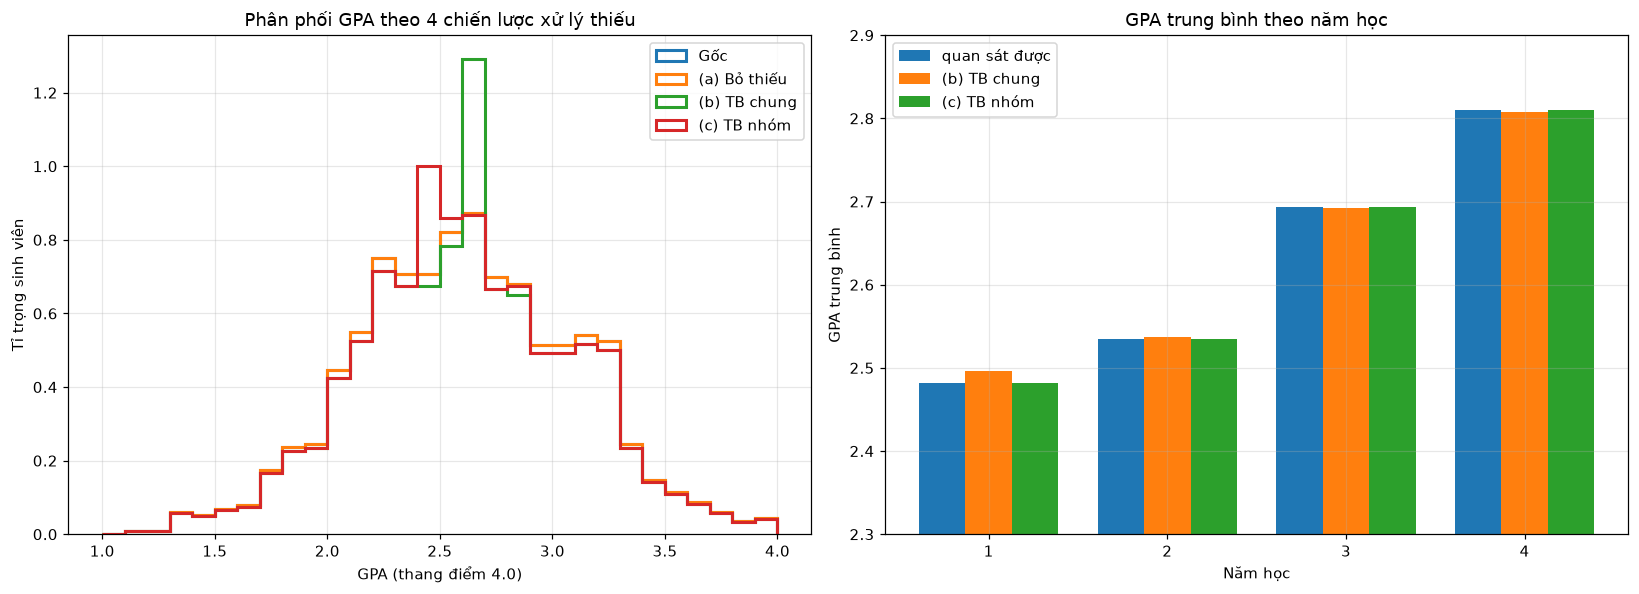

Task 4 ĐẠT.


In [30]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)
# TODO: vẽ 4 đường lên ax1 — gốc, A, B, C.
#       Dùng ax1.hist(..., bins=bins, histtype="step", density=True, linewidth=2, label=...)
#       density=True là bắt buộc: A chỉ có 1145 điểm còn B, C có 1200,
#       nếu vẽ theo số đếm thì bốn đường không so sánh được với nhau.
ax1.hist(original, bins=bins, histtype="step", density=True, linewidth=2, label="Gốc")
ax1.hist(A, bins=bins, histtype="step", density=True, linewidth=2, label="(a) Bỏ thiếu")
ax1.hist(B, bins=bins, histtype="step", density=True, linewidth=2, label="(b) TB chung")
ax1.hist(C, bins=bins, histtype="step", density=True, linewidth=2, label="(c) TB nhóm")

# TODO: nhãn trục + title + ax1.legend()
ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Tỉ trọng sinh viên")
ax1.set_title("Phân phối GPA theo 4 chiến lược xử lý thiếu")
ax1.legend()

# TODO: vẽ biểu đồ cột nhóm lên ax2 — GPA trung bình từng năm dưới
#       "quan sát được" / "(b)" / "(c)". Gợi ý: x = np.arange(len(by_year)), w = 0.26,
#       rồi ax2.bar(x - w, ...), ax2.bar(x, ...), ax2.bar(x + w, ...)
x = np.arange(len(by_year))
w = 0.26
ax2.bar(x - w, by_year["quan sát được"], width=w, label="quan sát được")
ax2.bar(x, by_year["(b) TB chung"], width=w, label="(b) TB chung")
ax2.bar(x + w, by_year["(c) TB nhóm"], width=w, label="(c) TB nhóm")

# TODO: ax2.set_ylim(2.3, 2.9) để nhìn rõ chênh lệch
ax2.set_xticks(x)
ax2.set_xticklabels(by_year.index)
ax2.set_ylim(2.3, 2.9)

# TODO: nhãn trục + title + ax2.legend()
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA trung bình")
ax2.set_title("GPA trung bình theo năm học")
ax2.legend()

fig.tight_layout()
# TODO: fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")

plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")

### Kết luận của bạn

> *(Nhấp đúp để sửa.)*

1. Tỉ lệ thiếu `gpa` **không đều** giữa các năm học. Con số cụ thể:
Năm 1 có tỉ lệ thiếu cao đột biến lên tới 10.80%. Ngược lại, các khối Năm 2, Năm 3 và Năm 4 chỉ bị thiếu lác đác ở mức 2.83%, 1.40% và 1.27%

2. Nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại? Vì sao điều đó nguy hiểm?
Nhóm Năm 1 thiếu nhiều nhất và có GPA quan sát được thấp nhất toàn trường chỉ đạt 2.48. Điều này cực kỳ nguy hiểm vì dữ liệu đang bị "thiếu có hệ thống". Việc xử lý sai sẽ làm sai lệch hoàn toàn thành tích của nhóm sinh viên yếu nhất trường

3. Chiến lược (a) làm gì với **thành phần mẫu**? Nhìn tỷ trọng sinh viên năm 1 trước/sau.
Nhìn tỷ trọng sinh viên năm 1 trước/sau. Chiến lược xóa bỏ dòng làm suy giảm nghiêm trọng tỷ trọng đại diện của sinh viên Năm 1, rớt từ 30.08% xuống chỉ còn 28.12%. Cấu trúc nhân khẩu học của toàn bộ mẫu dữ liệu đã bị biến dạng

4. Chiến lược (b) giữ nguyên trung bình chung 2.6148 — nghe có vẻ an toàn. Nhưng nhìn bảng theo từng năm: nó làm gì với trung bình của **năm 1**?
Chiến lược điền trung bình chung đã khống điểm trung bình của khối Năm 1 từ thực tế 2.4815 lên mức giả tạo 2.4959 tăng lệch 0.0144. Việc lấy điểm cao của các anh chị năm cuối bù cho năm nhất đã san lấp mất sự phân hóa tự nhiên

5. Vì sao `std` giảm ở cả (b) và (c)? Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy?
Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy? Cả (b) và (c) đều nhét hàng loạt các giá trị y hệt nhau vào phần lõi của phân phối, khiến độ lệch chuẩn giảm từ 0.4871 xuống 0.4758 và 0.4766. Nếu tính khoảng tin cậy, dải tin cậy sẽ bị thu hẹp lại một cách giả tạo, khiến chúng ta lạc quan thái quá về độ chính xác của tập dữ liệu

6. **Cách nào ít làm méo nhất, và vì sao?**
Cách (c) điền bằng trung bình nhóm là giải pháp an toàn nhất. Nó giữ nguyên cấu trúc mẫu dữ liệu, đồng thời bảo toàn độ lệch bằng 0 cho mức GPA trung bình thực tế của từng năm học riêng biệt

7. Theo bạn **vì sao** sinh viên năm 1 thiếu GPA nhiều hơn hẳn? Nếu giả thuyết của bạn đúng thì cách xử lý đúng nhất có còn là "điền" nữa không?
Đây rất có thể là các Tân sinh viên vừa trúng tuyển, chưa kết thúc học kỳ đầu tiên nên chưa phát sinh điểm GPA. Nếu giả thuyết này đúng, hành động "điền" điểm là thao tác ngụy tạo dữ liệu. Cách xử lý duy nhất đúng đắn là tách riêng nhóm thiếu điểm này thành một tệp phân tích độc lập với nhãn "Chưa có điểm tích lũy"

---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

In [ ]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
# Lưu ý: seaborn 0.13 + matplotlib 3.11 sẽ in một MatplotlibDeprecationWarning về
# tham số `vert` ở boxplot. Đó là warning nội bộ của seaborn, vô hại, không phải lỗi của bạn.
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

# TODO: sns.histplot(data=..., x="gpa", hue=..., bins=30, multiple="stack",
#                    palette="colorblind", ax=axa)
#       Gợi ý: tách theo năm học. Đừng truyền thẳng cột số `nam_hoc` vào `hue`
#       (seaborn sẽ coi nó là biến liên tục và tô thang màu gradient);
#       hãy tạo trước một cột nhãn dạng chuỗi.
# TODO: nhãn trục + title

# TODO: sns.boxplot(data=sv, x="khoa", y="gpa", order=..., hue="khoa",
#                   palette="colorblind", legend=False, ax=axb)
# TODO: nhãn trục + title
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
# TODO: fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác

### Bản nào truyền đạt tốt hơn?

> *(Nhấp đúp để sửa. Đừng trả lời "Seaborn đẹp hơn" — hãy nói **bản nào giúp người đọc trả lời câu hỏi nhanh hơn**, và đánh đổi là gì.)*

1. Bản Seaborn cho bạn thêm thông tin gì mà bản matplotlib ở Task 1 không có? …
2. Có thông tin nào bản matplotlib thể hiện rõ hơn không? …
3. Bao nhiêu dòng code mỗi bản? Đánh đổi giữa số dòng và khả năng kiểm soát nằm ở đâu? …
4. Nếu phải đưa một trong hai vào báo cáo gửi Ban Giám hiệu, bạn chọn bản nào, vì sao? …

---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [x] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [x] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [x] `banhang_sach.csv` — 900 dòng × 8 cột
- [x] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [x] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [x] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [x] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [x] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [x] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [x] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [x] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không?
Có. Toàn bộ notebook được xây dựng bằng mã lệnh thao tác dữ liệu tự động, loại bỏ hoàn toàn các can thiệp thủ công. Logic xử lý chuỗi, ép kiểu và điền khuyết đều được thiết lập bằng công thức. Chỉ cần người chạy có cùng tệp sinhvien.csv và banhang_raw.csv, thao tác Restart Kernel and Run All Cells chắc chắn sẽ cho ra kết quả trùng khớp 100% từ các con số doanh thu đến tỷ trọng phần trăm

2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành.
Hoàn toàn không. Mọi thao tác trong nhật ký làm sạch của bài đều đi kèm lập luận phân tích dữ liệu và nghiệp vụ kế toán rõ ràng. Thay vì các lý do đối phó, mỗi dòng đều có căn cứ cụ thể như: "tránh tính doanh thu 2 lần", "bảo toàn 44.400.000 VNĐ doanh thu thật", "tránh sai lệch báo cáo phân bổ quỹ thưởng địa phương", hay "dựa trên hằng đẳng thức kế toán"

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.